<table>
    <tr>
    <th>
        <table>
            <tr>                                                                                   
                 <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Valeur</th>
                 <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Nom classe</th>
             </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">0</th>
                <th  style="font-size:150%;text-align:left">basophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">1</th>
                <th  style="font-size:150%;text-align:left;">eosinophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">2</th>
                <th  style="font-size:150%;text-align:left">erythroblast</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">3</th>
                <th  style="font-size:150%;text-align:left">immature</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">4</th>
                <th  style="font-size:150%;text-align:left;">lymphocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">5</th>
                <th  style="font-size:150%;text-align:left;">monocyte</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">6</th>
                <th  style="font-size:150%;text-align:left;">neutrophil</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">7</th>
                <th  style="font-size:150%;text-align:left">platelet</th>
            </tr>            
        </table>
    </th>
    <th>     
        <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>BloodMNIST<br> Standardized Biomedical Images</div>        
        <img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/bloodMNIST8.png" width="512">
    </th>
    </tr>
</table>   

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://github.com/MedMNIST/MedMNIST/tree/main">Veuillez vous référer à la page Github officielle pour plus de détails.</a></div>

>> **site du projet** : https://medmnist.com/

>> **site de données** : https://zenodo.org/records/10519652

In [1]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ['KERAS_BACKEND'] = 'tensorflow'  
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
# os.environ['TF_XLA_FLAGS']='--tf_xla_auto_jit=1,--tf_xla_always_defer_compilation=true'
# os.environ['XLA_FLAGS']='--xla_backend_optimization_level=0,--xla_gpu_autotune_level=4,--xla_gpu_disable_ptxas_optimizations=true,--xla_gpu_use_cudnn_batchnorm_level=2'
# os.environ['TF_GPU_ALLOCATOR']='cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

In [2]:
! nvidia-smi

Fri Sep 12 11:30:57 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.247.01             Driver Version: 535.247.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0  On |                  N/A |
| 30%   56C    P5              86W / 350W |    969MiB / 24576MiB |     13%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [3]:
import os, numpy as np, pandas as pd, seaborn as sns, warnings, sys, pickle
from matplotlib import pyplot as plt
from datetime import datetime as dt

import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=2)

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

tf.get_logger().setLevel('ERROR')# Suppress TensorFlow logging (2)

E0000 00:00:1757669458.150209   95945 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757669458.153011   95945 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757669458.159924   95945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757669458.159931   95945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757669458.159932   95945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757669458.159932   95945 computation_placer.cc:177] computation placer already registered. Please check linka

In [5]:
print("Tensorflow\t : %s\tCUDA %s\tGPU %s\tXLA %s\nKeras\t\t : %s\nPandas\t\t : %s\nNumPy\t\t : %s"%
      (tf.__version__, 
       tf.test.is_built_with_cuda(), 
       tf.test.is_built_with_gpu_support(), 
       tf.test.is_built_with_xla(), 
       tf.keras.__version__, 
       pd.__version__, 
       np.__version__))

Tensorflow	 : 2.19.1	CUDA True	GPU True	XLA True
Keras		 : 3.12.0
Pandas		 : 2.3.2
NumPy		 : 1.26.4


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation les GPUs presents </div></b>

In [6]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')

if len(physical_devices) >  0 :
    for i, gpu in enumerate(physical_devices):
        tf.config.experimental.set_memory_growth(physical_devices[i], True)

    strategy = tf.distribute.experimental.CentralStorageStrategy()
    print('Le système est initialisé avec {0:d} GPUs'.format(strategy.num_replicas_in_sync))

Le système est initialisé avec 1 GPUs


I0000 00:00:1757669459.199264   95945 service.cc:152] XLA service 0x56135a82c1f0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757669459.199280   95945 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1757669459.267728   95945 service.cc:152] XLA service 0x5613559cf420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757669459.267742   95945 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1757669459.271947   95945 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21458 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document </div></b>

In [7]:
palette = [
            "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", "#d1e5f0", "#fddbc7",
            "#ffffcb", "#12e193", "#d8dcd6", "#ffdaf0", "#dfc5fe", "#f5054f", "#a0450e",
            "#0339f8", "#f4320c", "#fec615", "#017a79", "#85a3b2", "#fe2f4a", "#a00498", "#b04e0f",
            "#0165fc", "#ff724c", "#fddc5c", "#11875d", "#89a0b0", "#fe828c", "#cb00f5", "#b75203",
            "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#ffb7ce", "#c071fe", "#ca6b02",
            "#92c5de", "#f4a582", "#fef69e", "#18d17b", "#c5c9c7", "#ffcfdc", "#caa0ff", "#cb7723",
            "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#ffdaf0", "#dfc5fe", "#d8863b",
            "#030764", "#be0119", "#dbb40c", "#005249", "#3c4142", "#cb0162", "#5d1451", "#653700",
            "#040348", "#67001f", "#b27a01", "#002d04", "#000000", "#a0025c", "#490648", "#3c0008"
          ]
# sns.palplot(sns.color_palette(palette))

In [8]:
nom_projet                = "MedMNIST-donnees"
repertoireProjet          = os.getcwd()
repertoireEnregistrement  = repertoireProjet +'/'+nom_projet+ '/repertoire.images'
repertoireSauvegardes     = repertoireProjet +'/'+nom_projet+ '/repertoire.sauvegardes'

def controleExistenceRepertoire(directory, create_if_needed=True):
    """Voir si le répertoire existe. S'il n'existe pas il est créé."""
    path_exists = os.path.exists(directory)
    if path_exists:
        if not os.path.isdir(directory):
            raise Exception("Trouvé le nom "+directory+" mais c'est un fichier, pas un répertoire")
            return False
        return True
    if create_if_needed:
        os.makedirs(directory)
        
controleExistenceRepertoire(repertoireEnregistrement)
controleExistenceRepertoire(repertoireSauvegardes)

def sauvegarderImage( fichier):
    """Enregistrez la figure. Appelez la méthode juste avant plt.show ()."""
    plt.savefig(os.path.join(repertoireEnregistrement,
                             fichier+f"--{dt.now().strftime('%Y_%m_%d_%H.%M.%S')}.png"), 
                             dpi=600, 
                             bbox_inches='tight')


    
def sauvegarderModelPoids(model, fichierPoids, repertoireSauvegardes=repertoireSauvegardes):
    """Enregistrez les poids du modèle Keras."""
    if fichierPoids != None:
        controleExistenceRepertoire(repertoireSauvegardes)
        nomFichier = os.path.join(repertoireSauvegardes, '{}.keras'.format(fichierPoids))
        model.save_weights(nomFichier)

def sauvegarderModel(model, fichier, repertoireSauvegardes=repertoireSauvegardes):
    """Enregistrez le modèle Keras."""
    if fichier != None:
        controleExistenceRepertoire(repertoireSauvegardes)
        nomFichier = os.path.join(repertoireSauvegardes, '{}.keras'.format(fichier))
        model.save(nomFichier)

def lectureModelPoids(model, fichier, repertoireSauvegardes=repertoireSauvegardes):
    """Si le fichier existe, il est chargé et retourne True, sinon retourne False."""
    nomFichier = os.path.join(repertoireSauvegardes, '{}.keras'.format(fichier))
    if os.path.exists(nomFichier):
        if os.path.isfile(nomFichier):
            model.load_weights(nomFichier)
            return True
    return False

def lectureModel(self, model_filename):
    """Si le fichier existe, il est chargé et retourne True, sinon retourne False."""
    fullpath = self.saved_models_dir+'/'+model_filename+'.keras'
    if os.path.exists(fullpath):
        if os.path.isfile(fullpath):
            model = load_model(fullpath)
            return model
    return None    

def sauvegardeHistorique(model,
                         repertoireSauvegardes,
                         nomSauvegarde='one_hidden_layer_history_batch_size_1'):

    history = pd.DataFrame( model.history)
    history.reset_index(inplace=True)
    history.rename(columns={'index':'epoch'},inplace=True)
    history.to_parquet(os.path.join(repertoireSauvegardes,f'{nomSauvegarde}.gzip'),compression='gzip', engine='pyarrow') 
    return history

def afficheHistoriqueEntrainement(history, palette):
    fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(48,16));
    markersize = 8
    linewidth=2
    
    graph = sns.lineplot(x='epoch', 
                         y='accuracy',  
                         data=history,
                         ax=ax[0],      
                         label='accuracy',
                         err_style=None, 
                         marker='o',
                         markersize=markersize,
                         linewidth=linewidth,
                         color=palette[0],
                         );
    graph = sns.lineplot(x='epoch', 
                         y='val_accuracy',  
                         data=history,
                         ax=ax[0],      
                         label='val_accuracy',
                         err_style=None, 
                         marker='o',
                         markersize=markersize,
                         linewidth=linewidth,
                         color=palette[1],
                         );
    
    graph = sns.lineplot(x='epoch', 
                         y='loss',  
                         data=history,
                         ax=ax[1],      
                         label='loss',
                         err_style=None, 
                         marker='o',
                         markersize=markersize,
                         linewidth=linewidth,
                         color=palette[0],
                         );
    graph = sns.lineplot(x='epoch', 
                         y='val_loss',  
                         data=history,
                         ax=ax[1],      
                         label='val_loss',
                         err_style=None, 
                         marker='o',
                         markersize=markersize,
                         linewidth=linewidth,
                         color=palette[1],
                         );
    sauvegarderImage('afficheHistoriqueEntrainement')


def afficheDistributions(donnees, dictLabels, palette):
    fig, ax = plt.subplots(figsize=(24,12));
    
    affichage = pd.DataFrame(donnees["train_labels"].ravel(),columns=['label'])
    affichage['nom'] = affichage['label'].apply(lambda x: dictLabels[x])
    affichage = affichage.groupby(['nom']).label.count().reset_index().rename(columns={'label':'nombre'})
    affichage['%'] = affichage.nombre * 100 / affichage.nombre.sum()
    
    graph = sns.barplot(x="nom",y='nombre', data=affichage, palette=palette,  ax=ax)
    loc, labels = plt.xticks()
    graph.set_xticklabels(labels, rotation=90);
    
    for patche in graph.patches:
        if patche.get_height() > 0 :
            graph.text(
                        patche.get_x() + patche.get_width() / 2 ,
                        affichage['nombre'].mean()/2, 
                        f"{int(patche.get_height())} - {patche.get_height()*100/affichage.nombre.sum():0.2f}%",
                        color='black',
                        rotation='vertical',
        #                 size='large',
        #                 fontsize='large',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                        verticalalignment='center',
                        horizontalalignment='center',
                       )  
                
    ax.set_xlabel('');
    ax.set_ylabel('');
    sauvegarderImage('distributionCategories')


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Lecture des données à partir du disque</div></b>

In [9]:
def afficheDataset(donnees,labels,taille,image,dictLabels,cmap=None):
    plt.figure(figsize=(image, image))
    i=1
    for image, label in zip(donnees[:(taille*taille)],labels[:(taille*taille)]):
        ax = plt.subplot(taille, taille, i)
        if cmap is None :
            plt.imshow(image)
        else :
            plt.imshow(image,cmap='gray')
        plt.title(dictLabels[label[0]])
        plt.axis("off")
        i+=1

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>BloodMNIST - RGB</div></b>

The **BloodMNIST** is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection.<br>
It contains a total of **17,092** images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set.<br>
The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.

>> https://zenodo.org/records/10519652/files/bloodmnist.npz<br>
>> https://zenodo.org/records/10519652/files/bloodmnist_64.npz<br>
>> https://zenodo.org/records/10519652/files/bloodmnist_128.npz<br>
>> https://zenodo.org/records/10519652/files/bloodmnist_224.npz


In [10]:
donnees = np.load("../donnees/bloodmnist.npz")

In [11]:
print(f'apprentissage\t{donnees["train_images"].shape[0]}\nvalidation\t{donnees["val_images"].shape[0]}\ntest\t\t{donnees["test_images"].shape[0]}')

apprentissage	11959
validation	1712
test		3421


In [12]:
dictLabels = {0:"basophil",
              1:"eosinophil",
              2:"erythroblast",
              3:"immature",# granulocytes(myelocytes, metamyelocytes and promyelocytes)",
              4:"lymphocyte",
              5:"monocyte",
              6:"neutrophil",
              7:"platelet"}

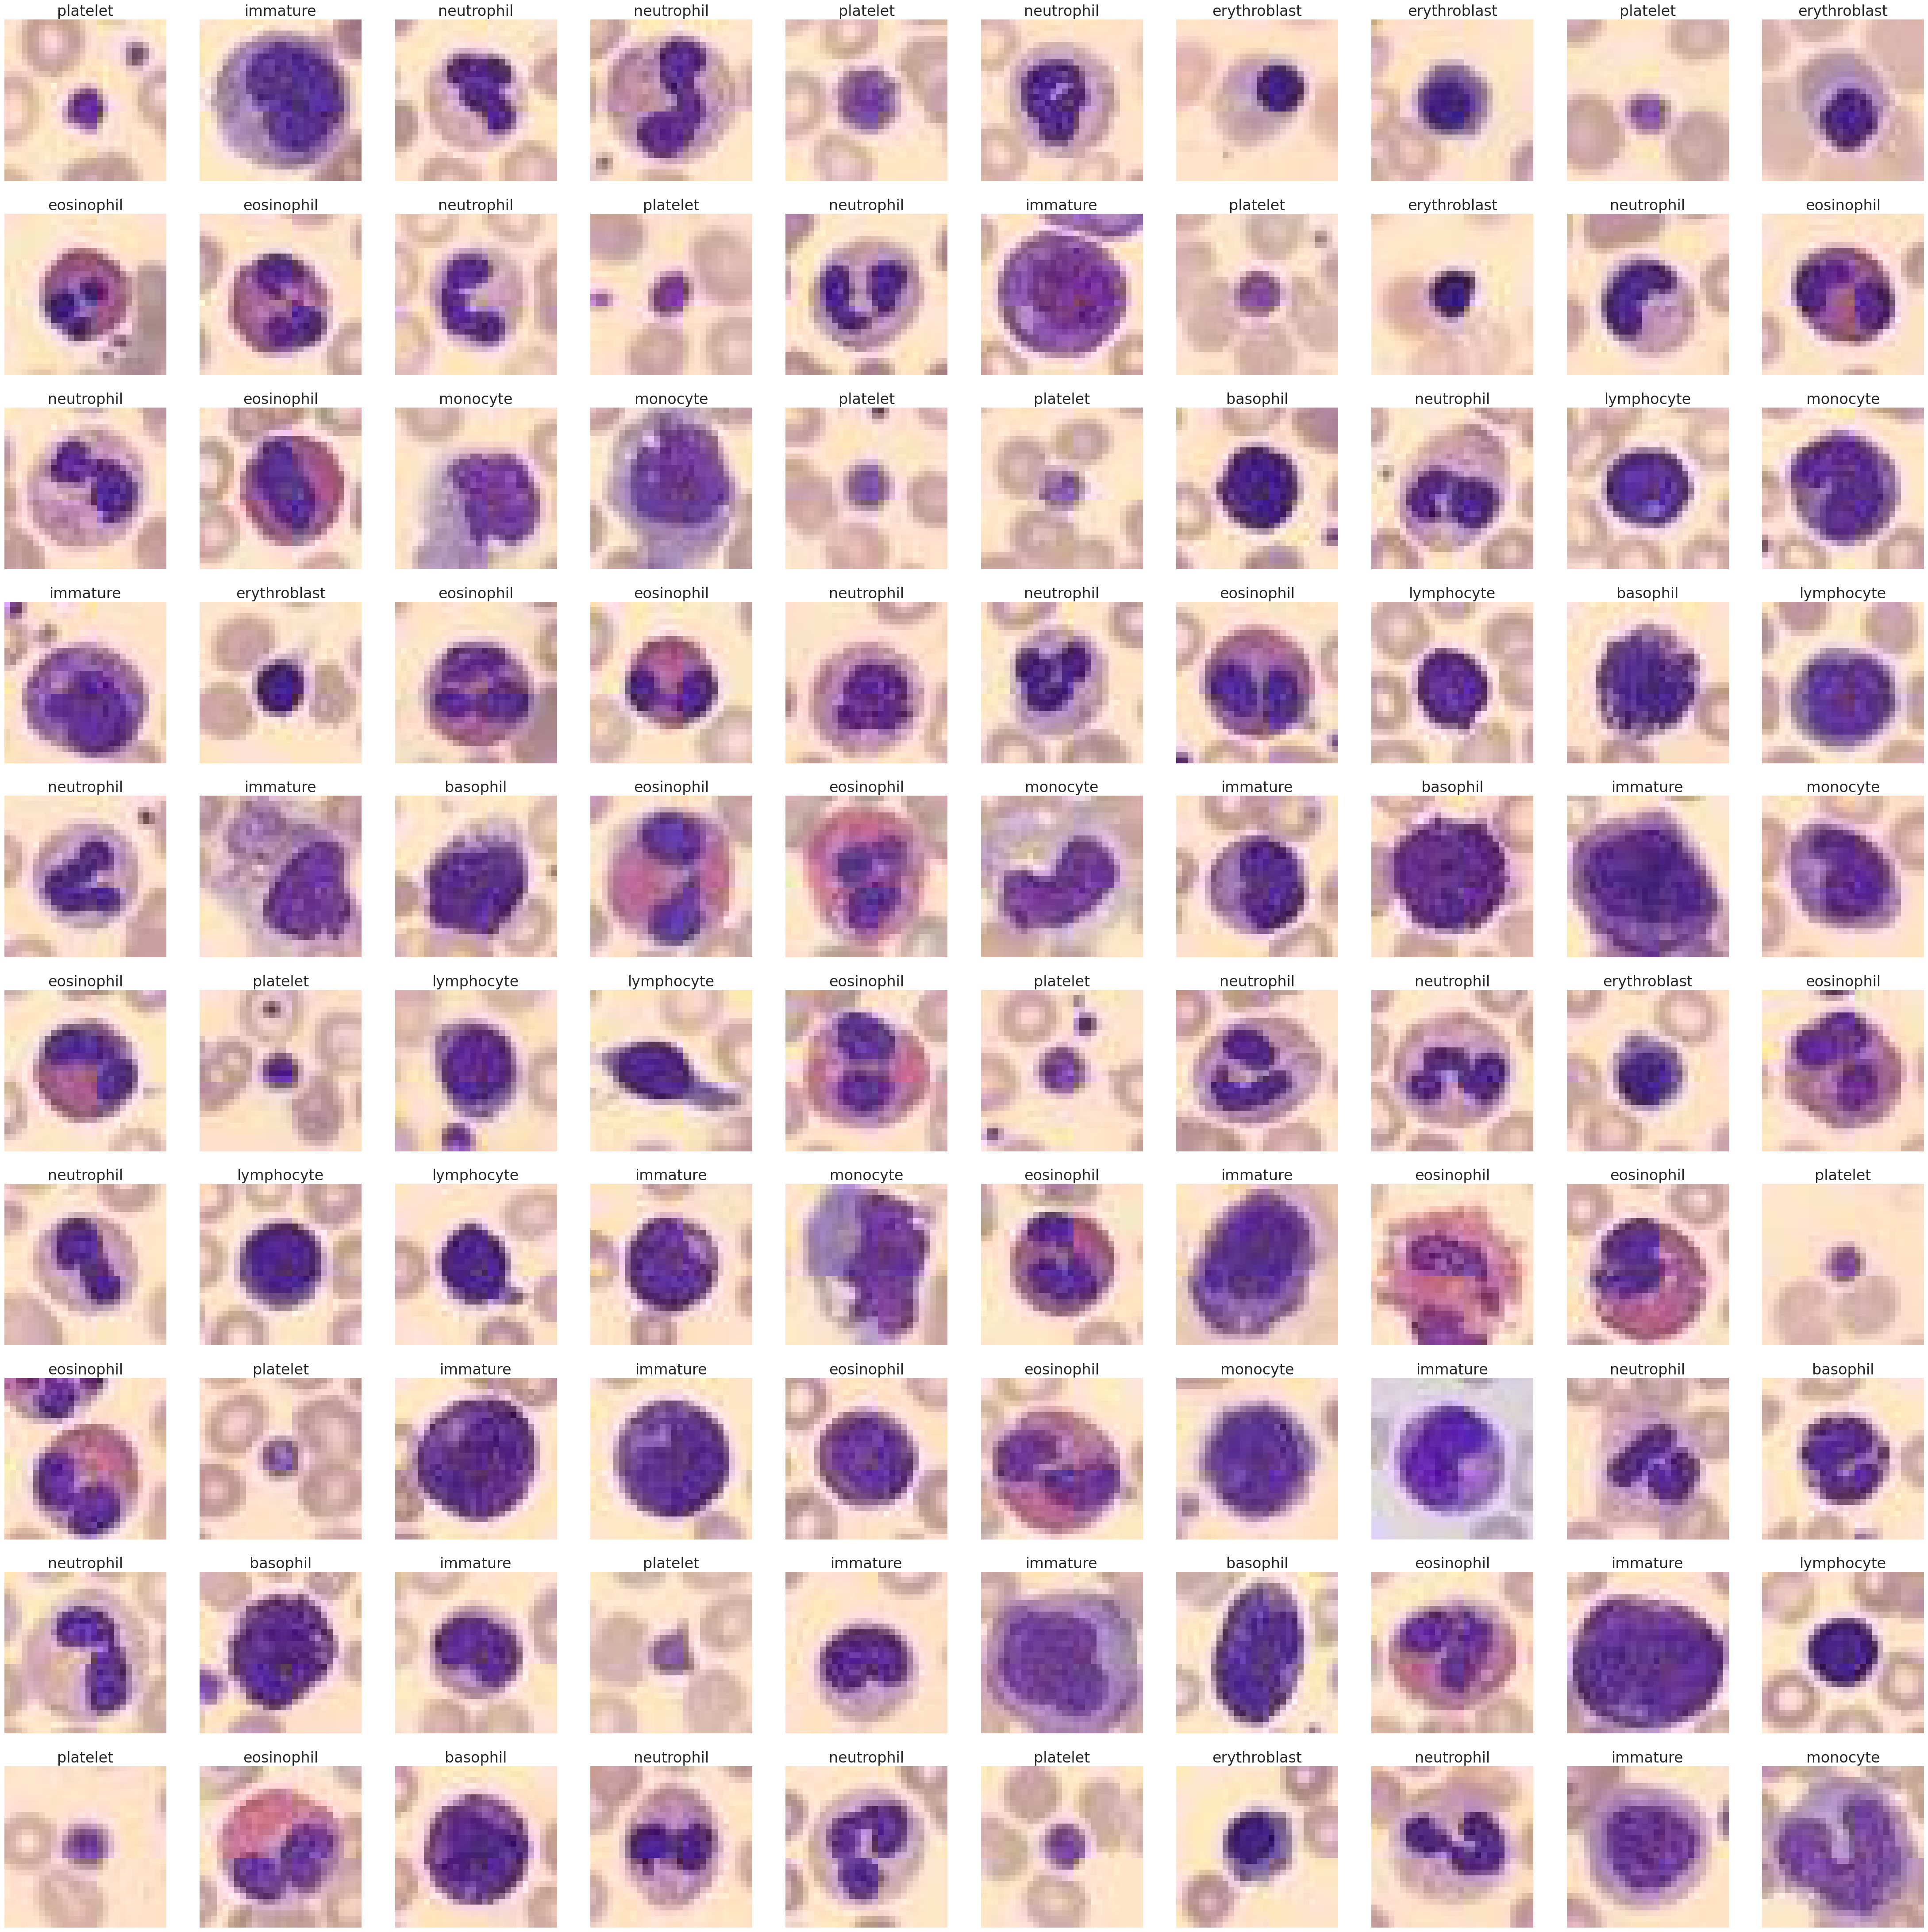

In [13]:
afficheDataset(donnees["train_images"],donnees["train_labels"],taille=10,image=56,dictLabels=dictLabels)

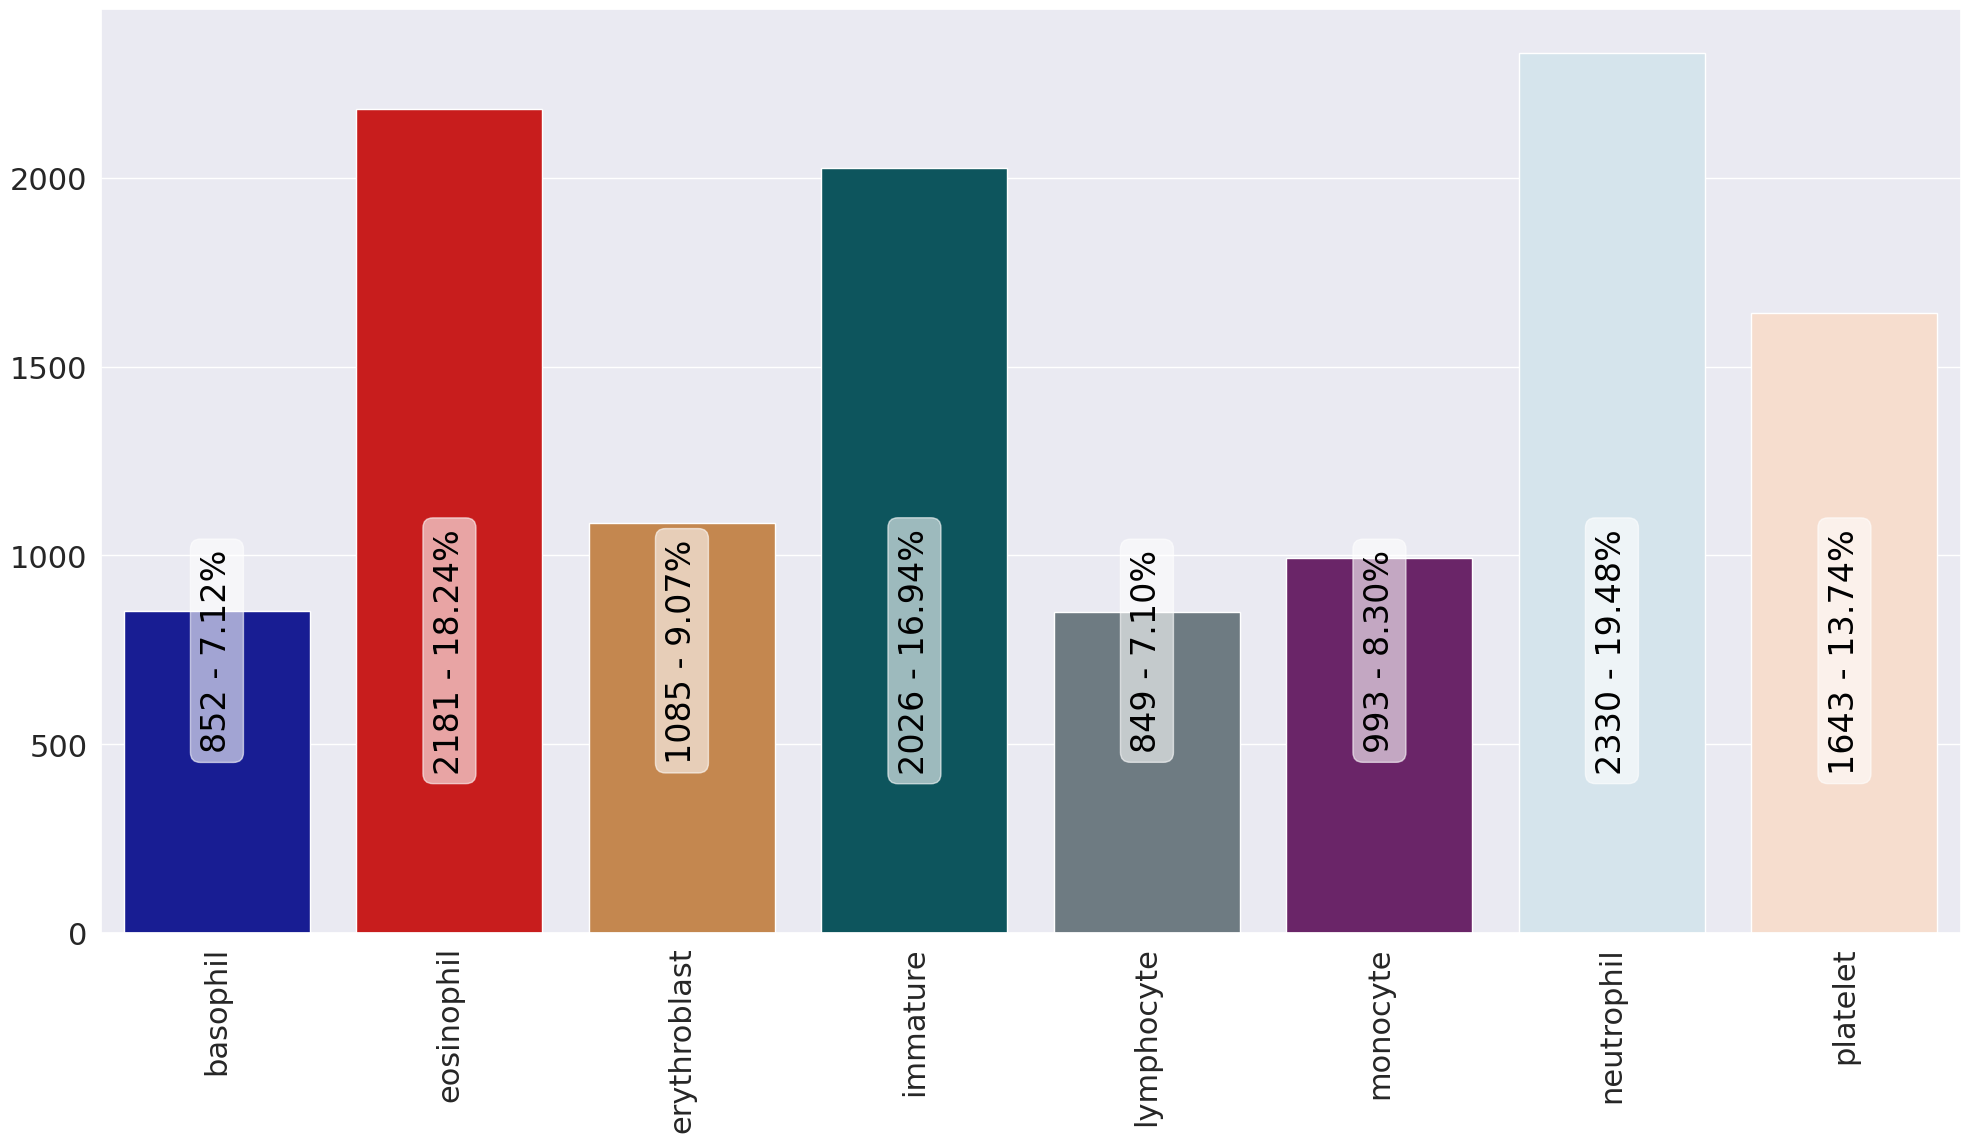

In [14]:
fig, ax = plt.subplots(figsize=(24,12));

affichage = pd.DataFrame(donnees["train_labels"].ravel(),columns=['label'])
affichage['nom'] = affichage['label'].apply(lambda x: dictLabels[x])
affichage = affichage.groupby(['nom']).label.count().reset_index().rename(columns={'label':'nombre'})
affichage['%'] = affichage.nombre * 100 / affichage.nombre.sum()

graph = sns.barplot(x="nom",y='nombre', data=affichage, palette=palette,  ax=ax)
loc, labels = plt.xticks()
graph.set_xticklabels(labels, rotation=90);

for patche in graph.patches:
    if patche.get_height() > 0 :
        graph.text(
                    patche.get_x() + patche.get_width() / 2 ,
                    affichage['nombre'].mean()/2, 
                    f"{int(patche.get_height())} - {patche.get_height()*100/affichage.nombre.sum():0.2f}%",
                    color='black',
                    rotation='vertical',
    #                 size='large',
    #                 fontsize='large',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                    verticalalignment='center',
                    horizontalalignment='center',
                   )  
            
ax.set_xlabel('');
ax.set_ylabel('');

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Création des fichiers TFRecors</div></b>

In [15]:
!ls -al ../donnees/BloodMNIST_Images

total 104
drwxrwxr-x 10 razvan razvan  4096 sept. 12 11:18 .
drwxrwxr-x 48 razvan razvan  4096 sept. 12 11:28 ..
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 basophil
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 eosinophil
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 erythroblast
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 ig
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 lymphocyte
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 monocyte
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 neutrophil
drwxrwxr-x  2 razvan razvan 12288 sept.  7 10:52 platelet


In [16]:
image_size=(36,36,3)
batch_size=1024

repertoire = "../donnees/BloodMNIST_Images/" 

pipelineApprentissage = tf.keras.utils.image_dataset_from_directory(
    directory=repertoire,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=image_size[:2],
    seed=123456789,
    subset="training",
    validation_split=0.1,
)

pipelineValidation = tf.keras.utils.image_dataset_from_directory(
    directory=repertoire,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=image_size[:2],
    seed=123456789,
    subset="validation",
    validation_split=0.1,
)

l = os.listdir("../donnees/BloodMNIST_Images/");l.sort()
dictLabels = {i:nom for i,nom in enumerate(l)}    

Found 1560 files belonging to 8 classes.
Using 1404 files for training.
Found 1560 files belonging to 8 classes.
Using 156 files for validation.


In [17]:
dictLabels

{0: 'basophil',
 1: 'eosinophil',
 2: 'erythroblast',
 3: 'ig',
 4: 'lymphocyte',
 5: 'monocyte',
 6: 'neutrophil',
 7: 'platelet'}

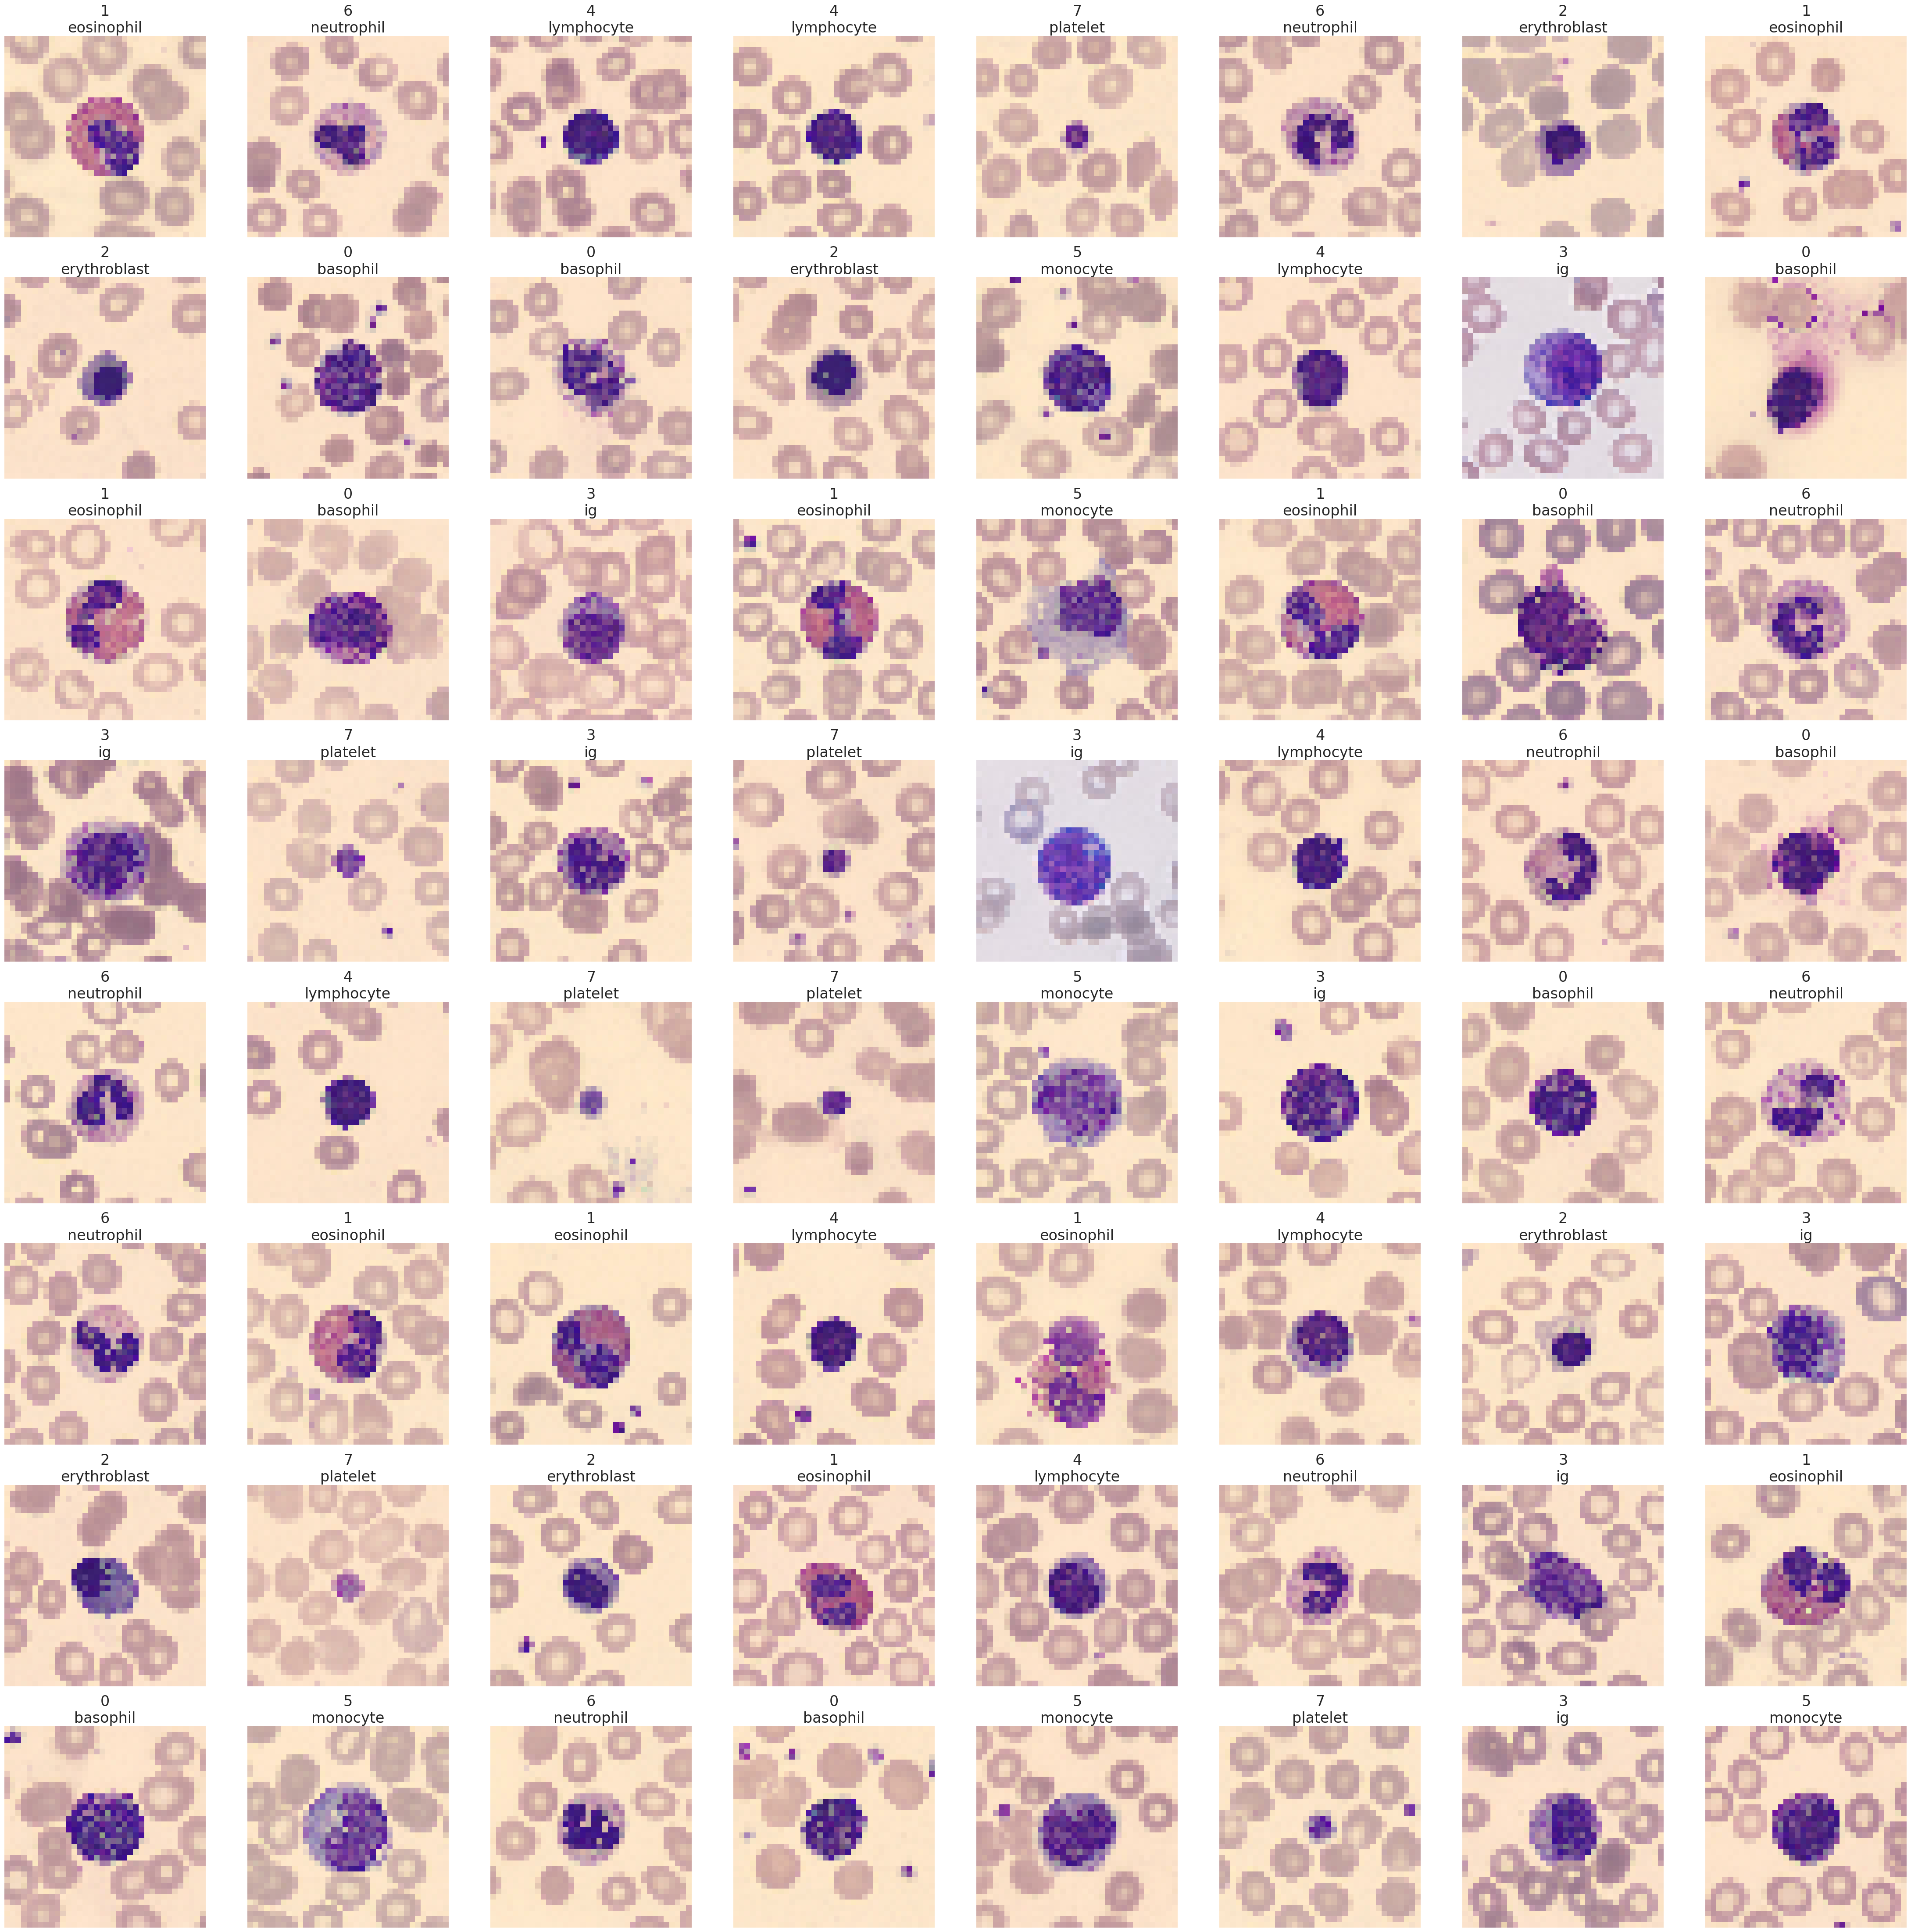

In [18]:
plt.figure(figsize=(56, 56))
for images, labels in pipelineApprentissage.take(2):
    for i in range(64):
        ax = plt.subplot(8, 8, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label = np.argmax(labels[i])
        plt.title(f'{label}\n{dictLabels[label]}')
        plt.axis("off")

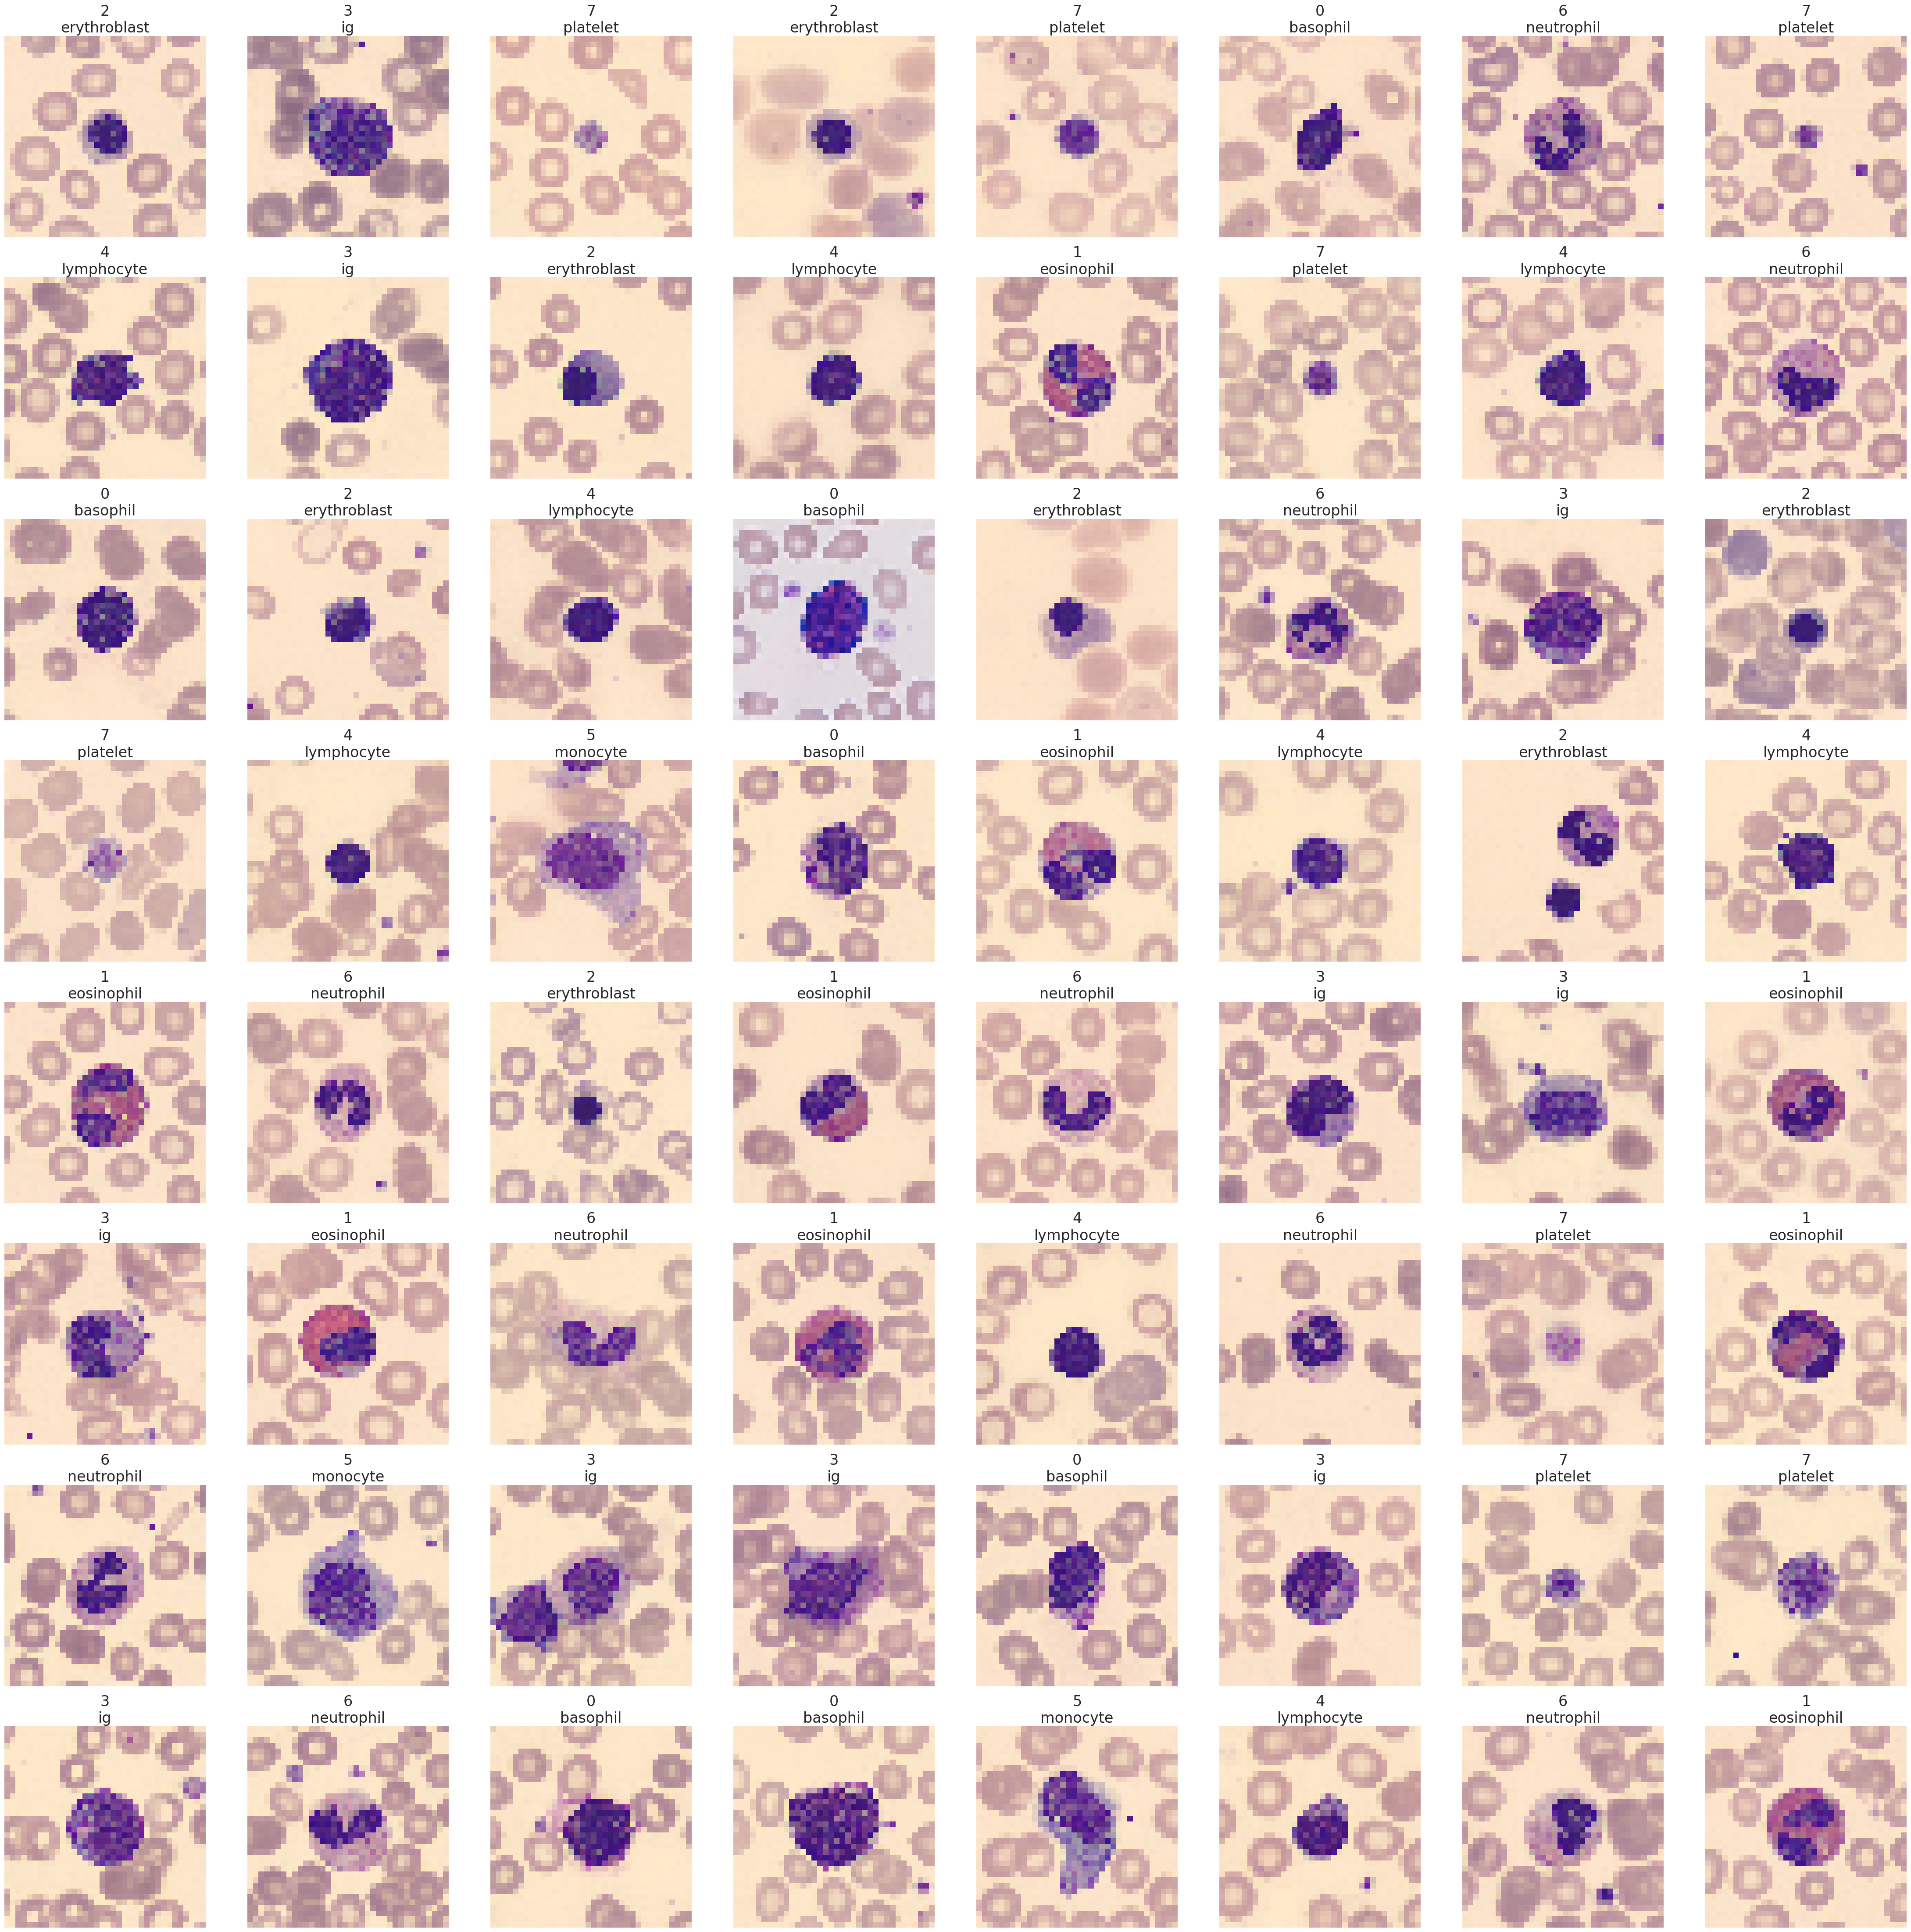

In [19]:
plt.figure(figsize=(56, 56))
for images, labels in pipelineValidation.take(2):
    for i in range(64):
        ax = plt.subplot(8, 8, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label = np.argmax(labels[i])
        plt.title(f'{label}\n{dictLabels[label]}')
        plt.axis("off")